In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import pearsonr, spearmanr, chi2_contingency

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from category_encoders import BinaryEncoder

from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import train_test_split

In [3]:
df_raw = pd.read_csv("../data\credit_card_frauds.csv")

<>:1: SyntaxWarning: invalid escape sequence '\c'
<>:1: SyntaxWarning: invalid escape sequence '\c'
C:\Users\User\AppData\Local\Temp\ipykernel_18656\3235312259.py:1: SyntaxWarning: invalid escape sequence '\c'
  df_raw = pd.read_csv("../data\credit_card_frauds.csv")


**División de los datos**

Dividimos los datos nada mas empezar para que no se produzca data leakage.

In [ ]:
X = df_raw.drop('is_fraud', axis=1)
y = df_raw['is_fraud']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.20, 
    random_state=42, 
    stratify=y
)

#df = pd.concat([X_train, y_train], axis=1)
df_test = pd.concat([X_test, y_test], axis=1)



In [10]:
# 1. Unir X_train e y_train en un solo DataFrame temporal
df_temp = pd.concat([X_train, y_train], axis=1)

# 2. Separar las clases del conjunto de entrenamiento
df_fraud = df[df['is_fraud'] == 1]
df_non_fraud = df[df['is_fraud'] == 0]

# 3. Mantener todos los fraudes y calcular cuántos legítimos necesitamos (proporción 80/20)
n_fraud = len(df_fraud)
n_non_fraud_needed = n_fraud * 4 # Esto hace que el fraude sea el 20% del total

# 4. Aplicar Undersampling solo a los legítimos
df_non_fraud_resampled = df_non_fraud.sample(n=n_non_fraud_needed, random_state=42)

# 5. Guardar el resultado final en df_train y mezclar
df_train = pd.concat([df_non_fraud_resampled, df_fraud], axis=0)
df_train = df_train.sample(frac=1, random_state=42).reset_index(drop=True)

# 6. Actualizar X_train e y_train con los nuevos datos balanceados
X_train = df_train.drop(columns=['is_fraud'])
y_train = df_train['is_fraud']

# Verificación
print(f"Nuevo tamaño de df_train: {len(df_train)}")
print("Distribución de clases en el nuevo entrenamiento:")
print(y_train.value_counts(normalize=True) * 100)

Nuevo tamaño de df_train: 7130
Distribución de clases en el nuevo entrenamiento:
is_fraud
0    80.0
1    20.0
Name: proportion, dtype: float64


In [13]:
df_train.shape

(7130, 15)

In [17]:
df = pd.concat([X_train, y_train], axis=1)

In [18]:
df_train['is_fraud'].value_counts()

is_fraud
0    5704
1    1426
Name: count, dtype: int64

In [19]:
df['is_fraud'].value_counts()

is_fraud
0    5704
1    1426
Name: count, dtype: int64

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7130 entries, 0 to 7129
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   trans_date_trans_time  7130 non-null   datetime64[ns]
 1   merchant               7130 non-null   object        
 2   category               7130 non-null   object        
 3   amt                    7130 non-null   float64       
 4   city                   7130 non-null   object        
 5   state                  7130 non-null   object        
 6   lat                    7130 non-null   float64       
 7   long                   7130 non-null   float64       
 8   city_pop               7130 non-null   int64         
 9   job                    7130 non-null   object        
 10  dob                    7130 non-null   datetime64[ns]
 11  trans_num              7130 non-null   object        
 12  merch_lat              7130 non-null   float64       
 13  mer

In [21]:
#Convertimos en fehca las variables 'trans_Date_trans_time' y 'dob'

df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
df['dob'] = pd.to_datetime(df['dob'])

df_test['trans_date_trans_time'] = pd.to_datetime(df_test['trans_date_trans_time'])
df_test['dob'] = pd.to_datetime(df_test['dob'])

In [22]:
df.shape

(7130, 15)

In [23]:
df_test.shape

(67922, 15)

In [24]:
print(f"% Train: {df.shape[0]/df_raw.shape[0]} , % Test: {df_test.shape[0]/df_raw.shape[0]}")

% Train: 0.020994855818637425 , % Test: 0.20000176674803524


In [25]:
df.head()

,trans_date_trans_time,merchant,category,amt,city,state,lat,long,city_pop,job,dob,trans_num,merch_lat,merch_long,is_fraud
0,2019-10-06 23:17:26,Goyette Inc,shopping_net,1087.81,Yellowstone National Park,WY,44.7957,-110.6137,369,Materials engineer,1941-11-16,cffab9e23fb657588776fadd5a23361c,45.105570,-110.798043,1
1,2020-07-10 01:28:29,Mohr-Baye,shopping_net,14.18,Eugene,OR,44.0385,-123.0614,191096,"Scientist, physiological",1964-04-06,45d990efc698a450b2d63335105be851,43.645210,-122.164545,0
2,2020-03-03 20:22:02,Waelchi-Wol,kids_pets,49.74,Dumont,CO,39.7532,-105.6356,565,Mental health nurse,1978-08-27,501fe1538347e8c04e027507d39b5276,40.494624,-106.533707,0
3,2020-06-08 20:15:30,Jakubowski Inc,home,82.41,Meadville,MO,39.7795,-93.3014,964,Tourist information centre manager,1974-12-23,b2576a7217ae9ced659c36cf7e9ef43f,39.836890,-92.707328,0
4,2020-04-14 08:48:54,Luettgen PLC,gas_transport,52.72,Red River,NM,36.6659,-105.4694,606,"Surveyor, land/geomatics",1988-09-06,6a522600d5f5186cf6932336e4a23376,36.573235,-106.216465,0


In [26]:
df.describe(percentiles=[.25,.5,.75,.9,.95,.99]).T

,count,mean,min,25%,50%,75%,90%,95%,99%,max,std
trans_date_trans_time,7130,2020-01-14 03:38:46.392005376,2019-01-01 01:19:02,2019-07-17 07:44:01.500000,2019-12-30 09:06:55.500000,2020-07-19 20:36:12.750000128,2020-11-07 22:09:14.700000,2020-12-08 14:46:26.549999872,2020-12-27 20:27:04.710000128,2020-12-31 23:44:51,NaN
amt,7130.0,158.173265,1.0,13.15,54.715,126.2725,571.093,899.311,1094.9868,3459.18,271.692396
lat,7130.0,39.875846,20.0271,36.7651,39.7532,42.73,45.6892,47.4974,64.7556,66.6933,5.26733
long,7130.0,-110.777403,-165.6723,-120.6405,-111.0985,-100.6215,-93.6289,-91.8912,-90.318627,-89.6287,12.885855
city_pop,7130.0,112840.102665,46.0,471.0,1645.0,35439.0,320420.0,841711.0,1312922.0,2383912.0,309300.456578
dob,7130,1971-07-13 12:52:54.866760168,1927-09-09 00:00:00,1960-03-01 00:00:00,1973-12-26 00:00:00,1985-04-03 00:00:00,1991-04-13 00:00:00,1995-07-08 00:00:00,2000-08-16 00:00:00,2001-07-26 00:00:00,NaN
merch_lat,7130.0,39.867076,19.161782,36.944584,39.728346,42.394659,45.909227,47.765021,63.921035,67.510267,5.3062
merch_long,7130.0,-110.773223,-166.654993,-120.362448,-111.077641,-100.168078,-93.442337,-91.945014,-89.886574,-88.636465,12.89882
is_fraud,7130.0,0.2,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.400028


In [27]:
df.isnull().sum()

trans_date_trans_time    0
merchant                 0
category                 0
amt                      0
city                     0
state                    0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64

Eliminamos el numero de transferencia ('trans_num') ya que es un identificador único, y no va a aportar nada al modelo


In [28]:
df =df.copy()

In [29]:
df['age'] = (df['trans_date_trans_time'] - df['dob']).dt.days // 365
df_test['age'] = (df_test['trans_date_trans_time'] - df_test['dob']).dt.days // 365

# 3. Extraer información temporal de la transacción
# La hora es vital para detectar fraudes nocturnos
df['hour'] = df['trans_date_trans_time'].dt.hour
df_test['hour'] = df_test['trans_date_trans_time'].dt.hour

# El día de la semana (0=Lunes, 6=Domingo)
df['day_of_week'] = df['trans_date_trans_time'].dt.dayofweek
df['month'] = df['trans_date_trans_time'].dt.month
df['is_weekend'] = df['trans_date_trans_time'].dt.dayofweek.isin([5,6]).astype(int)

df_test['day_of_week'] = df_test['trans_date_trans_time'].dt.dayofweek
df_test['month'] = df_test['trans_date_trans_time'].dt.month
df_test['is_weekend'] = df_test['trans_date_trans_time'].dt.dayofweek.isin([5,6]).astype(int)

In [30]:
df.drop(columns='trans_num',inplace=True)
df_test.drop(columns='trans_num',inplace=True)

In [31]:
#Porcentaje de fraude (0=No fraude , 1=Fraude) respecto al total
df['is_fraud'].value_counts(normalize=True)*100

is_fraud
0    80.0
1    20.0
Name: proportion, dtype: float64

Observamos que nuestra target tiene un desequilibrio entre los fraudes y no fraudes. Por lo que vamos a darle más importancia a los que son fraudes (1) y reducir la cantidad datos de no fraudes (0). Lo vamos a hacer en un codigo separado para no cambiar todo el EDA entero.

In [32]:
"""""
#Separar las clases
df_fraud = df[df['is_fraud'] == 1]
df_non_fraud = df[df['is_fraud'] == 0]

#Configurar la proporción 70/30
#Definimos un tamaño total objetivo (por ejemplo, 100,000 registros)
total_target = 200000
n_non_fraud = int(total_target * 0.8) # 70,000 registros legítimos
n_fraud = int(total_target * 0.2)     # 30,000 registros de fraude

#Aplicar Undersampling a la clase mayoritaria (0)
df_non_fraud_resampled = df_non_fraud.sample(n=n_non_fraud, random_state=42)

#Aplicar Oversampling a la clase minoritaria (1)
#Usamos replace=True para duplicar registros de fraude hasta llegar a la meta
df_fraud_resampled = df_fraud.sample(n=n_fraud, replace=True, random_state=42)

#Combinar y mezclar (shuffling)
df_balanced = pd.concat([df_non_fraud_resampled, df_fraud_resampled], axis=0)
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

#Verificar resultados
print("Distribución de clases:")
print(df_balanced['is_fraud'].value_counts())
print("\nPorcentaje:")
print(df_balanced['is_fraud'].value_counts(normalize=True) * 100)

#Guardar el nuevo dataset
df_balanced.to_csv('../data/balanced_70_30_credit_card_frauds.csv', index=False)"""

'""\n#Separar las clases\ndf_fraud = df[df[\'is_fraud\'] == 1]\ndf_non_fraud = df[df[\'is_fraud\'] == 0]\n\n#Configurar la proporción 70/30\n#Definimos un tamaño total objetivo (por ejemplo, 100,000 registros)\ntotal_target = 200000\nn_non_fraud = int(total_target * 0.8) # 70,000 registros legítimos\nn_fraud = int(total_target * 0.2)     # 30,000 registros de fraude\n\n#Aplicar Undersampling a la clase mayoritaria (0)\ndf_non_fraud_resampled = df_non_fraud.sample(n=n_non_fraud, random_state=42)\n\n#Aplicar Oversampling a la clase minoritaria (1)\n#Usamos replace=True para duplicar registros de fraude hasta llegar a la meta\ndf_fraud_resampled = df_fraud.sample(n=n_fraud, replace=True, random_state=42)\n\n#Combinar y mezclar (shuffling)\ndf_balanced = pd.concat([df_non_fraud_resampled, df_fraud_resampled], axis=0)\ndf_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)\n\n#Verificar resultados\nprint("Distribución de clases:")\nprint(df_balanced[\'is_fraud\'].v

In [33]:
numeric_cols = df.select_dtypes(exclude='object').columns.tolist()
categoric_cols = df.select_dtypes(include=['object','bool']).columns.tolist()

In [34]:
numeric_cols

['trans_date_trans_time',
 'amt',
 'lat',
 'long',
 'city_pop',
 'dob',
 'merch_lat',
 'merch_long',
 'is_fraud',
 'age',
 'hour',
 'day_of_week',
 'month',
 'is_weekend']

In [35]:
categoric_cols

['merchant', 'category', 'city', 'state', 'job']

## Análisis Univariable y Preprocessing

**Variables Categóricas**

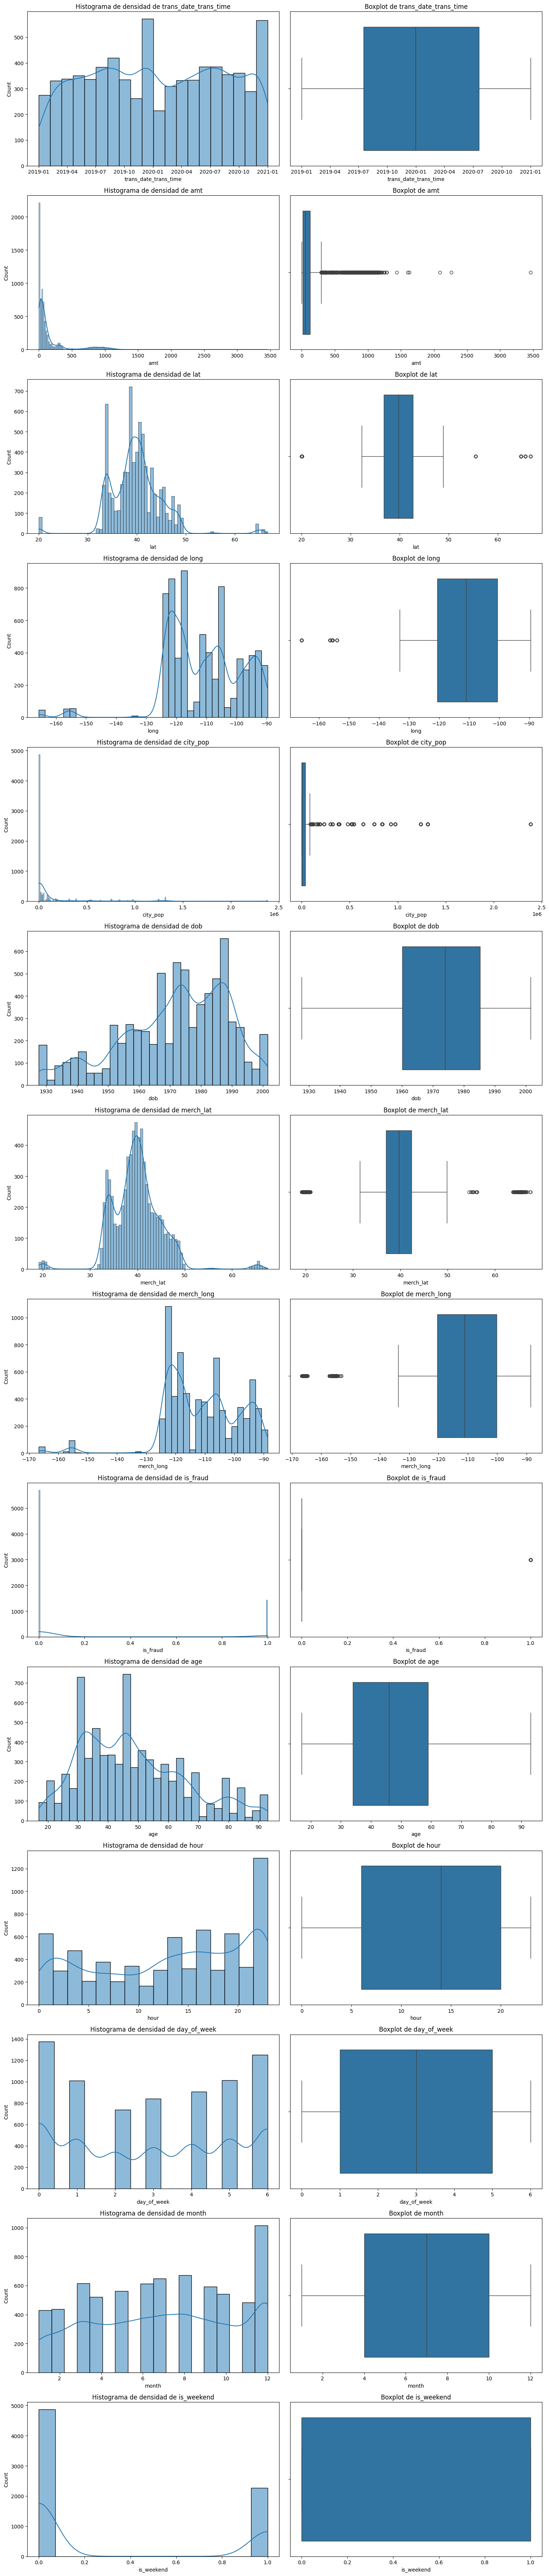

In [36]:
fig, axes = plt.subplots(nrows=len(numeric_cols), ncols=2, figsize=(15, 5 * len(numeric_cols)))

for i, column in enumerate(df[numeric_cols]):
    # Histograma de densidad
    sns.histplot(df[column], kde=True, ax=axes[i, 0])
    axes[i, 0].set_title(f'Histograma de densidad de {column}')
    
    # Boxplot
    sns.boxplot(x=df[column], ax=axes[i, 1])
    axes[i, 1].set_title(f'Boxplot de {column}')

plt.tight_layout()
plt.show()

Ver el número de registros y de porcentaje de outliers hay.

In [37]:
print("--- Resumen de Outliers ---")
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    perc = (len(outliers) / len(df)) * 100
    print(f"{col}: {len(outliers)} registros ({perc:.2f}%)")

--- Resumen de Outliers ---
trans_date_trans_time: 0 registros (0.00%)
amt: 1074 registros (15.06%)
lat: 165 registros (2.31%)
long: 155 registros (2.17%)
city_pop: 1379 registros (19.34%)
dob: 0 registros (0.00%)
merch_lat: 165 registros (2.31%)
merch_long: 155 registros (2.17%)
is_fraud: 1426 registros (20.00%)
age: 0 registros (0.00%)
hour: 0 registros (0.00%)
day_of_week: 0 registros (0.00%)
month: 0 registros (0.00%)
is_weekend: 0 registros (0.00%)


**Tratamiento de los outliers**

Hemos detectado que hay outliers en los siguientes campos: 'amt' ,'lat', 'long', city_pop', 'merch_lat', 'merch_long'. El tratamiento que le vamos a realizar es el siguiente:
1. 'amt' y 'city_pop', al tener muchísimos outliers, vamos a implementar un logaritmo para normalizar la distribución.
2. Para las variables geográficas 'lat', 'long', 'merch_lat' y 'merch_long', la estrategia que vamos a implementar es un RobustScaler. Como no queremos borrar los outliers, este método compensa su impacto escalando los datos mediante la mediana y el rango intercuartílico, evitando que los puntos más lejanos deformen el resto de la distribución.

In [38]:
amt_pop_cols = ['amt','city_pop']
df_amt_pop = df.copy()

for c in amt_pop_cols:
    df_amt_pop[c + '_log'] = np.log1p(df_amt_pop[c])

df[amt_pop_cols] = np.log1p(df[amt_pop_cols])


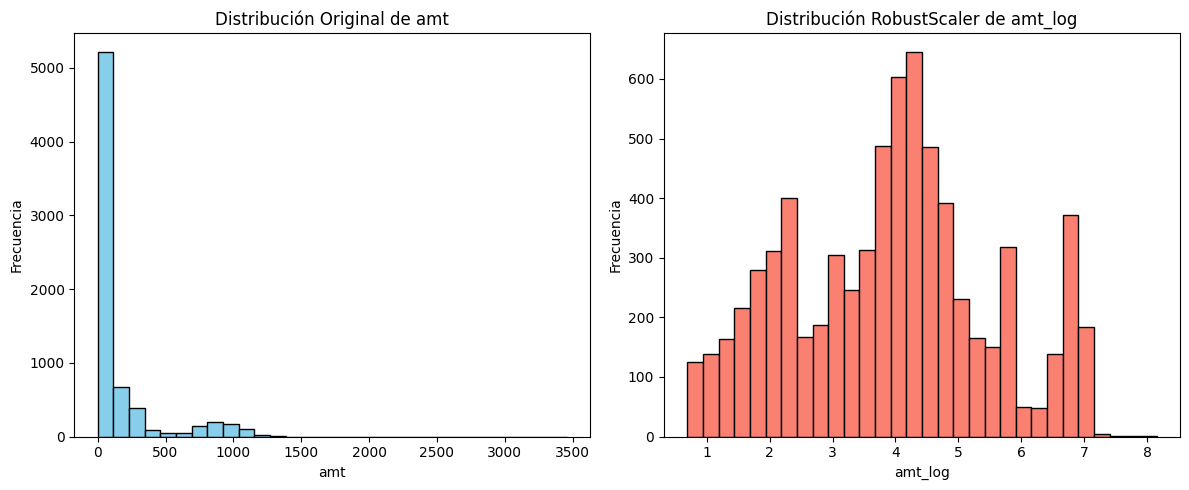

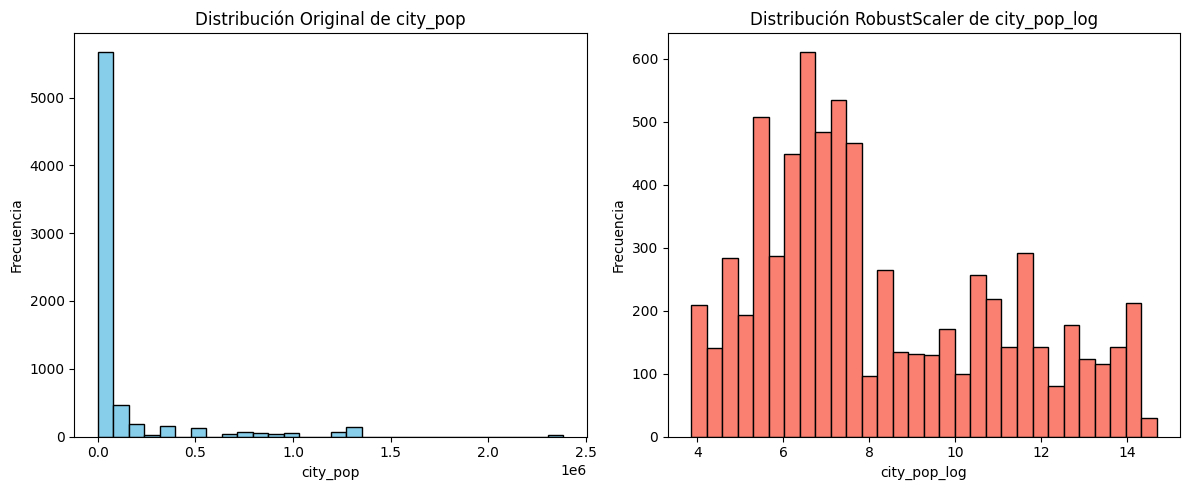

In [39]:
cols_to_plot = [
    ('amt', 'amt_log'),
    ('city_pop', 'city_pop_log'),
]

# Iniciamos el bucle
for col_orig, col_log in cols_to_plot:
    plt.figure(figsize=(12, 5))
    
    # 1. Histograma Original
    plt.subplot(1, 2, 1)
    plt.hist(df_amt_pop[col_orig], bins=30, color="skyblue", edgecolor="black")
    plt.title(f"Distribución Original de {col_orig}")
    plt.xlabel(col_orig)
    plt.ylabel("Frecuencia")
    
    # 2. Histograma Transformado
    plt.subplot(1, 2, 2)
    plt.hist(df_amt_pop[col_log], bins=30, color="salmon", edgecolor="black")
    plt.title(f"Distribución RobustScaler de {col_log}")
    plt.xlabel(col_log)
    plt.ylabel("Frecuencia")
    
    plt.tight_layout()
    plt.show()

Implementamos el Robust Scaler y vemos la normalización.

In [40]:
lat_long_cols = ['lat', 'long', 'merch_lat', 'merch_long']
df_lat_long_cols = df.copy()

scaler = RobustScaler()

# Creamos una lista de nombres nuevos: ['lat_robust', 'long_robust', ...]
new_cols = [c + '_robust' for c in lat_long_cols]

# Asignamos las 4 columnas de salida a los 4 nombres nuevos
df_lat_long_cols[new_cols] = scaler.fit_transform(df_lat_long_cols[lat_long_cols])
df[lat_long_cols] = scaler.fit_transform(df[lat_long_cols])

Vemos la comparación entre las variables Original vs la Robusta

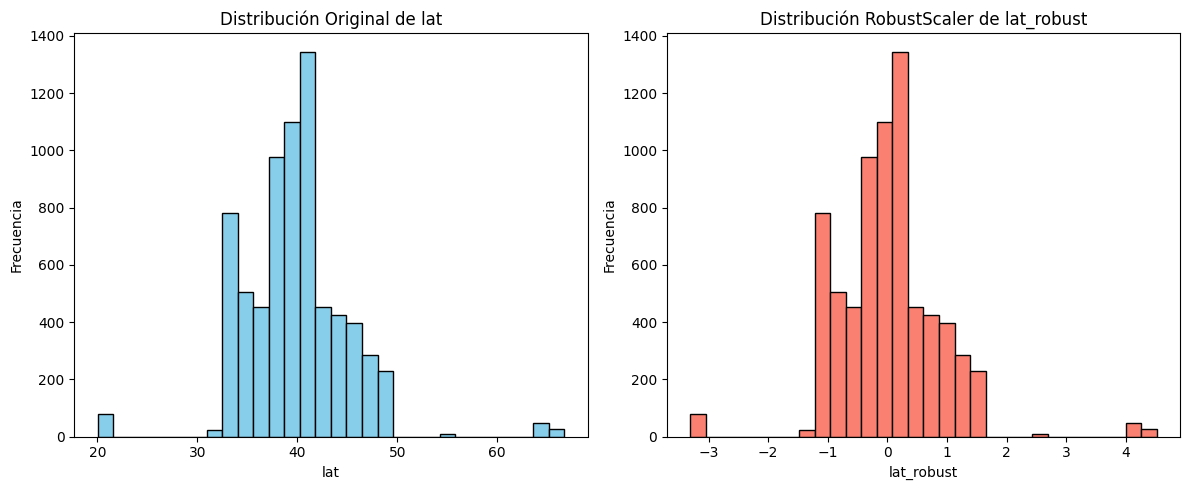

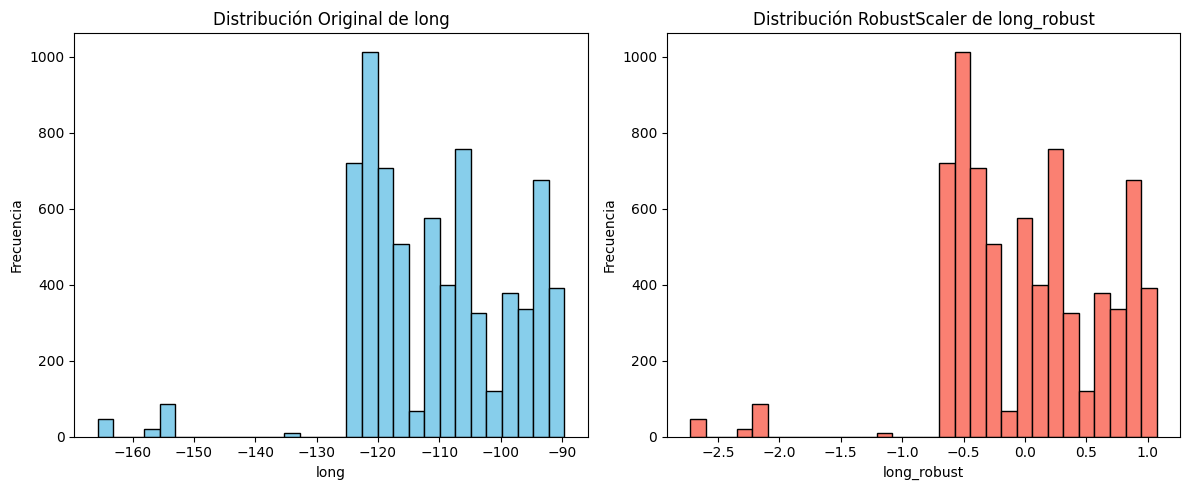

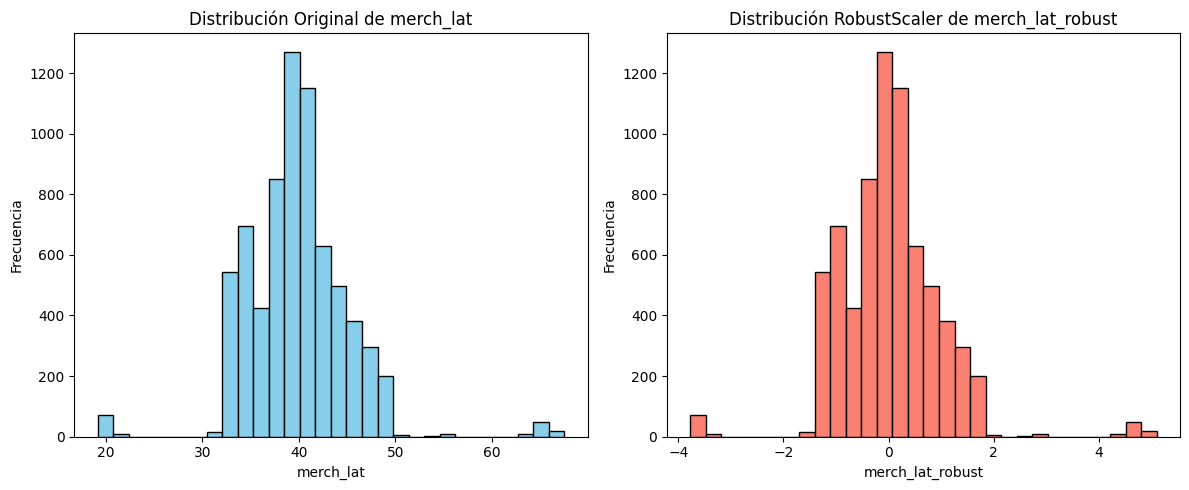

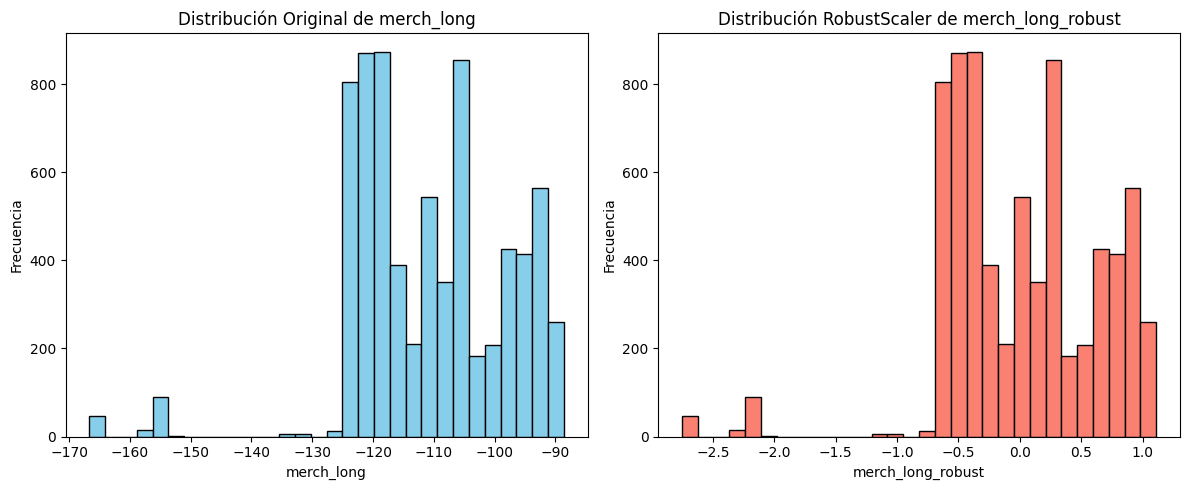

In [41]:
# Definimos las parejas de columnas (Original vs Robusta)
# Asegúrate de haber creado las columnas '_robust' antes
cols_to_plot = [
    ('lat', 'lat_robust'),
    ('long', 'long_robust'),
    ('merch_lat', 'merch_lat_robust'),
    ('merch_long', 'merch_long_robust')
]

# Iniciamos el bucle
for col_orig, col_rob in cols_to_plot:
    plt.figure(figsize=(12, 5))
    
    # 1. Histograma Original
    plt.subplot(1, 2, 1)
    plt.hist(df_lat_long_cols[col_orig], bins=30, color="skyblue", edgecolor="black")
    plt.title(f"Distribución Original de {col_orig}")
    plt.xlabel(col_orig)
    plt.ylabel("Frecuencia")
    
    # 2. Histograma Transformado
    plt.subplot(1, 2, 2)
    plt.hist(df_lat_long_cols[col_rob], bins=30, color="salmon", edgecolor="black")
    plt.title(f"Distribución RobustScaler de {col_rob}")
    plt.xlabel(col_rob)
    plt.ylabel("Frecuencia")
    
    plt.tight_layout()
    plt.show()

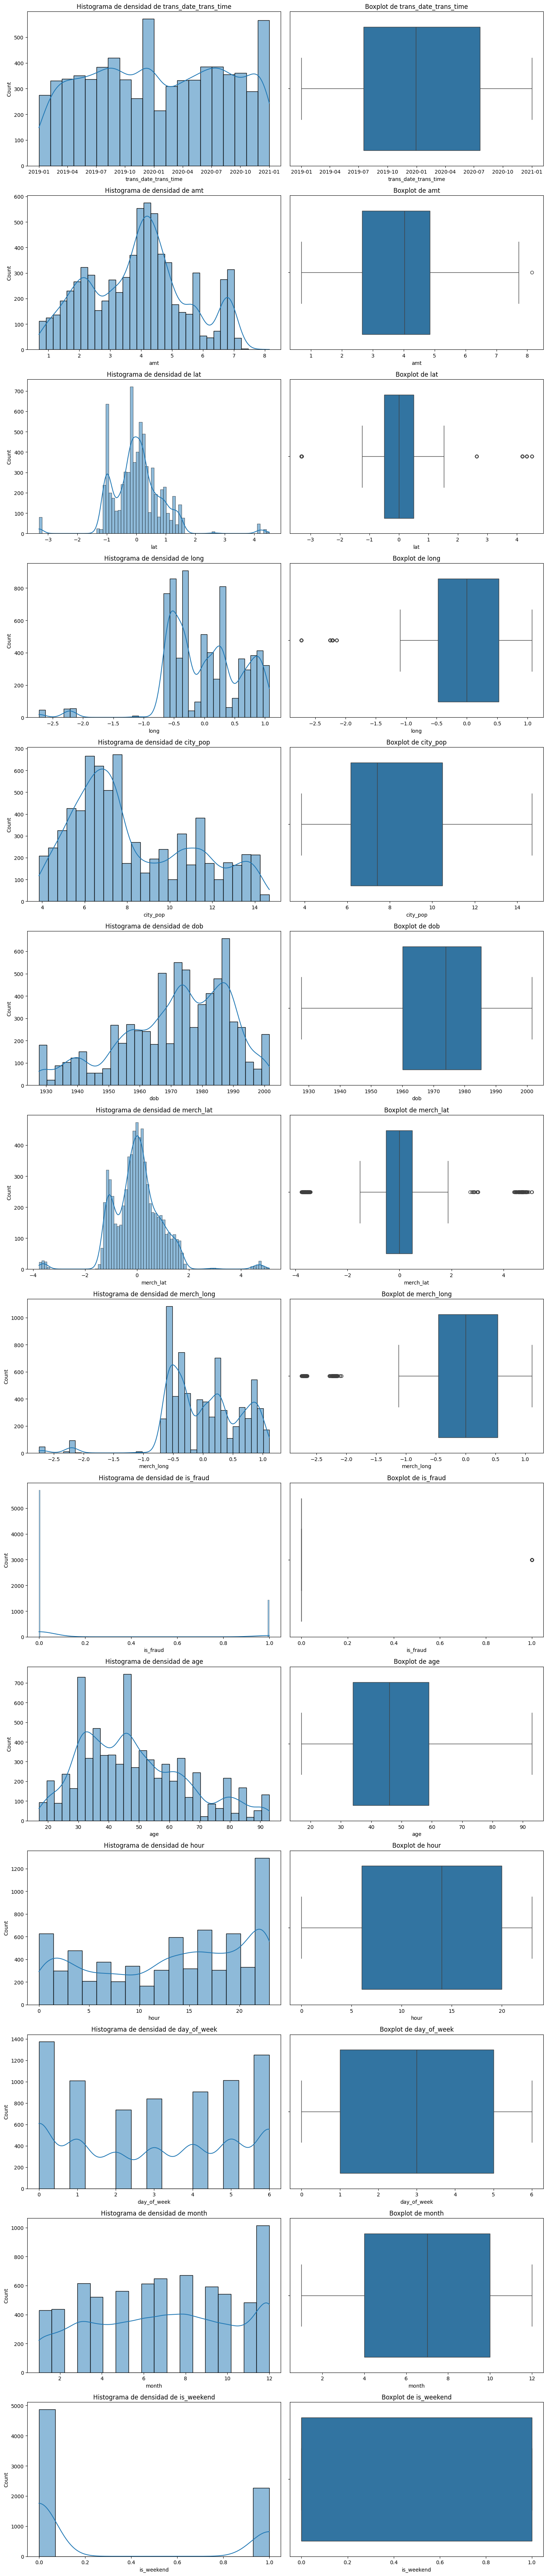

In [42]:
fig, axes = plt.subplots(nrows=len(numeric_cols), ncols=2, figsize=(15, 5 * len(numeric_cols)))

for i, column in enumerate(df[numeric_cols]):
    # Histograma de densidad
    sns.histplot(df[column], kde=True, ax=axes[i, 0])
    axes[i, 0].set_title(f'Histograma de densidad de {column}')
    
    # Boxplot
    sns.boxplot(x=df[column], ax=axes[i, 1])
    axes[i, 1].set_title(f'Boxplot de {column}')

plt.tight_layout()
plt.show()

**Columnas Categóricas**

In [43]:
#Creamos un nuevo DataFrame, con el fin de poner la variable target como categórica para la visualización, ya que se trataría de un bool.
df_fraud = df.copy()
df_fraud['is_fraud'] = df_fraud['is_fraud'].map({0: 'Legit', 1: 'Fraud'})

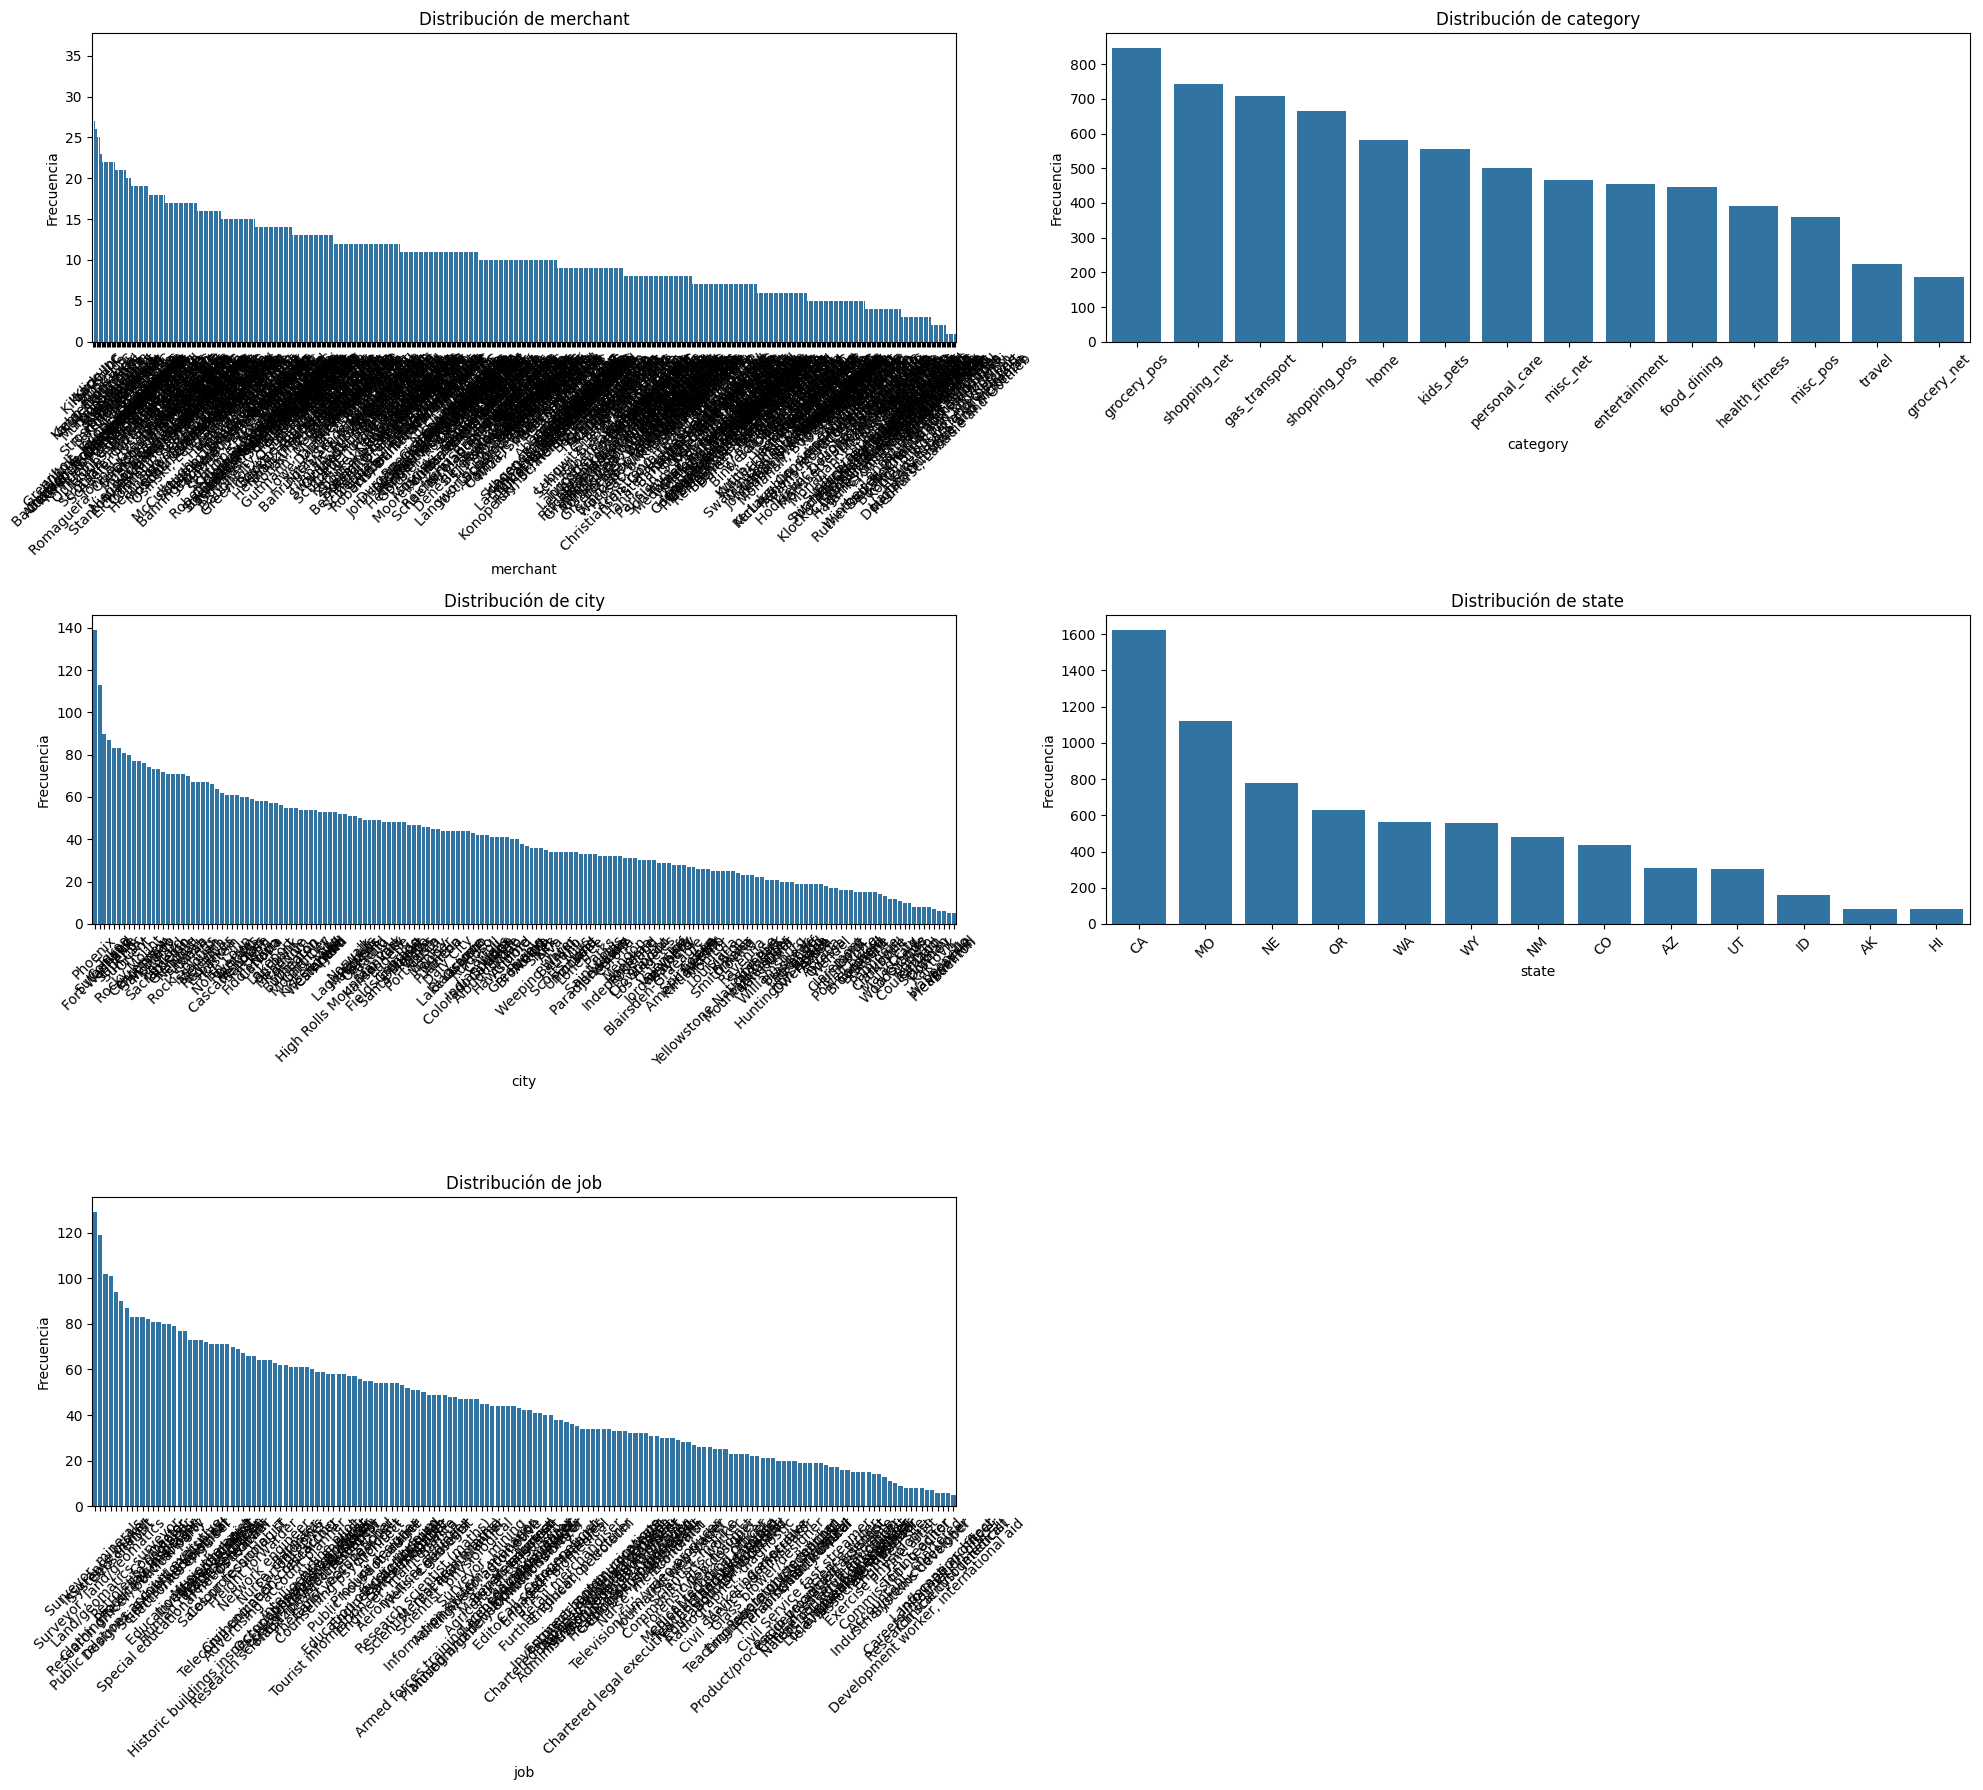

In [44]:
str_cols = df.select_dtypes(include=['object', 'bool', 'category']).columns

nrows = len(str_cols) // 2 + len(str_cols) % 2
fig, axs = plt.subplots(nrows=nrows, ncols=2, figsize=(20, 6 * nrows))

axs = axs.flatten()

for i, col in enumerate(str_cols):
    sns.countplot(data=df_fraud, x=col, order=df_fraud[col].value_counts().index, ax=axs[i])
    axs[i].set_title(f'Distribución de {col}')
    axs[i].set_xlabel(col)
    axs[i].set_ylabel('Frecuencia')
    axs[i].tick_params(axis='x', rotation=45)  # Rotar las etiquetas del eje x para mejor legibilidad

# Eliminar subplots vacíos si el número de columnas es impar
if len(str_cols) % 2 != 0:
    fig.delaxes(axs[-1])

plt.tight_layout()
plt.show()

Como vemos en los gráficos, podemos ver a simple vista que hay mucha cardinalidad. Por lo que, nos estamos planteando si eliminarla o no.

**Correlaciones**

In [45]:
# 2. Calculate the correlation matrix
corr_matrix = df[numeric_cols].corr()

# 3. Isolate the correlations with the target variable 'is_fraud'
target_corr = corr_matrix['is_fraud'].sort_values(ascending=False)

print(target_corr)

is_fraud                 1.000000
amt                      0.519774
age                      0.065137
hour                     0.062408
lat                      0.044410
merch_lat                0.041895
day_of_week              0.012873
is_weekend               0.002561
city_pop                -0.001190
long                    -0.024203
merch_long              -0.024557
dob                     -0.068633
trans_date_trans_time   -0.085477
month                   -0.093207
Name: is_fraud, dtype: float64


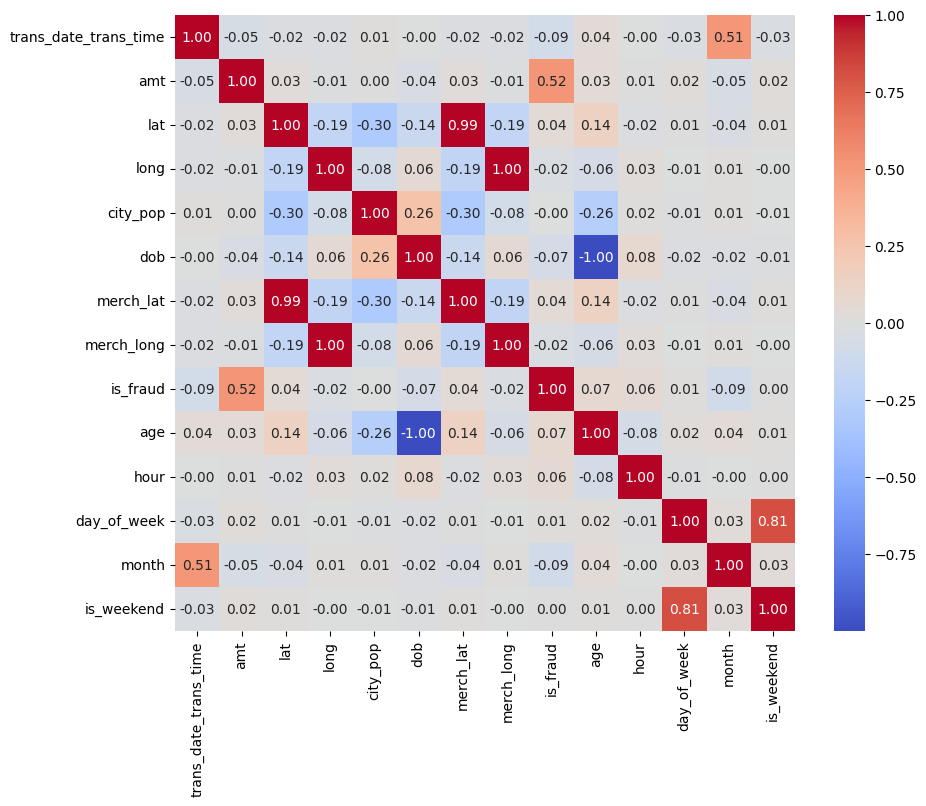

In [46]:
plt.figure(figsize=(10, 8))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.show()

**Correlaciones Pearson & Spearman**

In [47]:
# Creamos un subset del dataframe original
df_corr = df[numeric_cols]

# 2. Calculamos las matrices de correlación
pearson_matrix = df_corr.corr(method='pearson')
spearman_matrix = df_corr.corr(method='spearman')


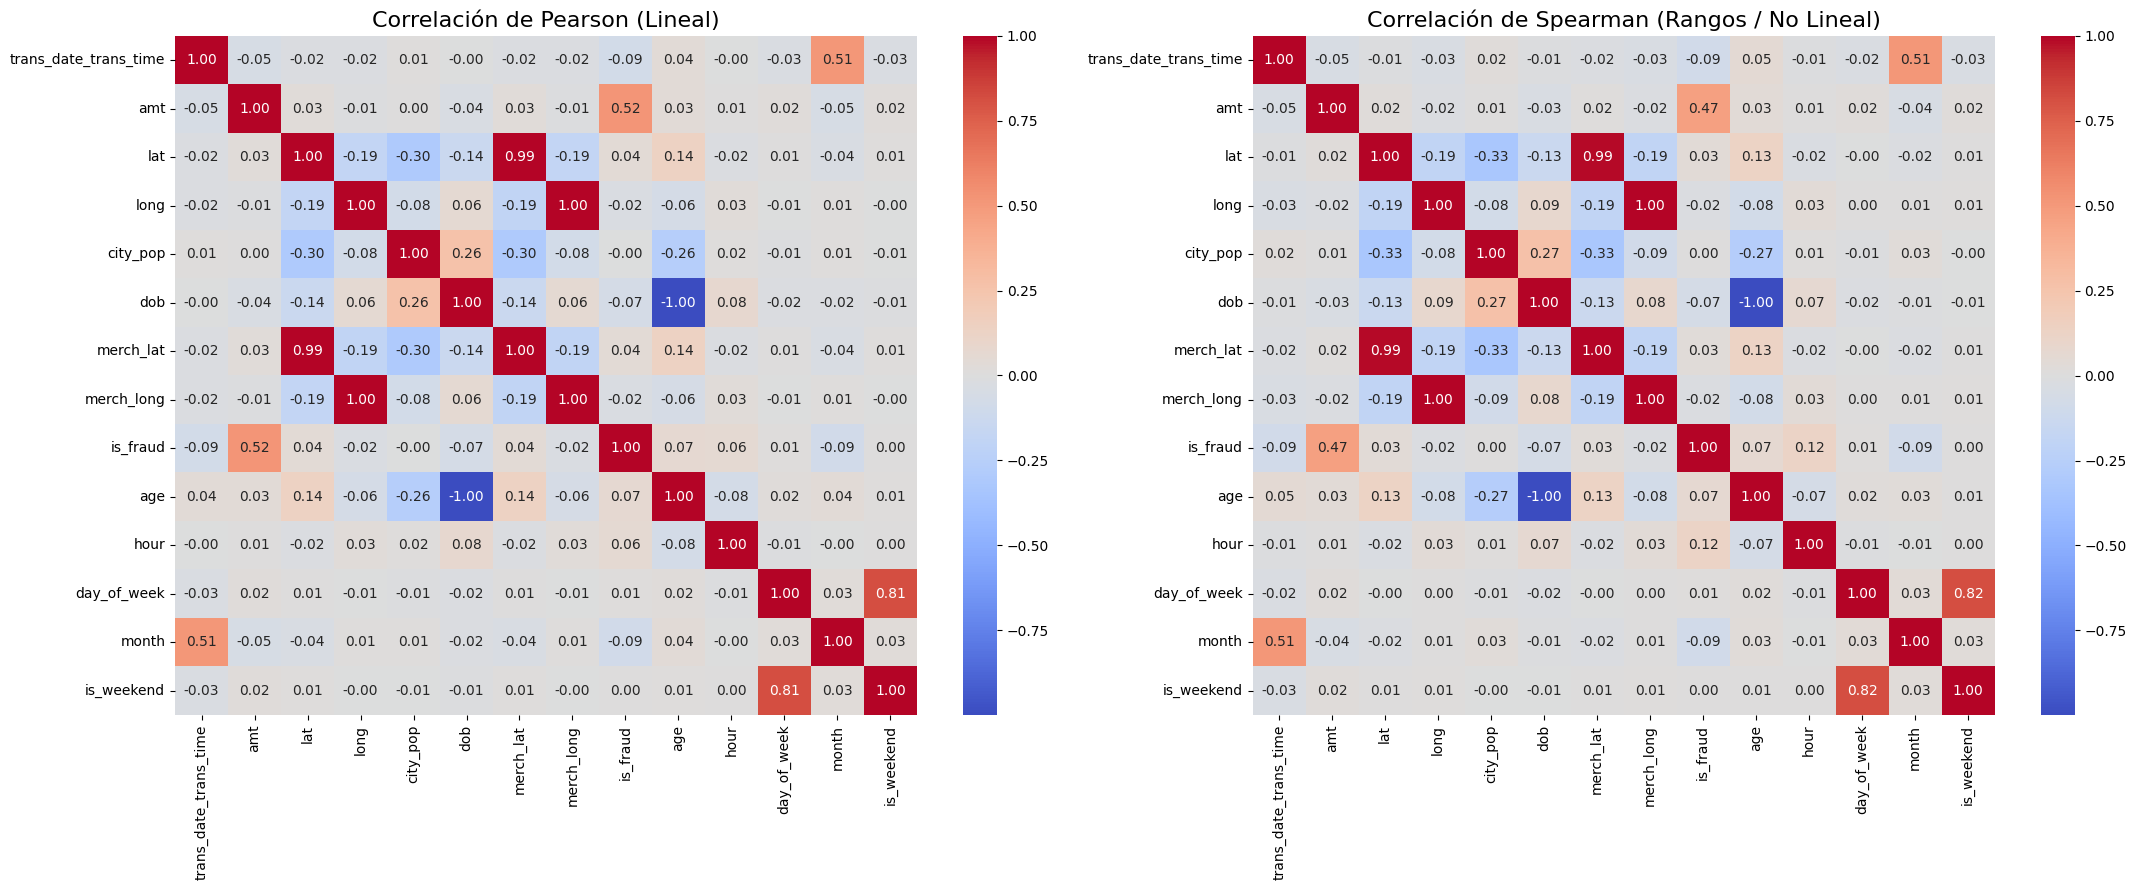

In [48]:
# 3. Configuramos la figura con dos subplots (uno al lado del otro)
fig, ax = plt.subplots(1, 2, figsize=(22, 9))

# Heatmap de Pearson
sns.heatmap(pearson_matrix, annot=True, fmt=".2f", cmap='coolwarm', ax=ax[0], cbar=True)
ax[0].set_title('Correlación de Pearson (Lineal)', fontsize=16)

# Heatmap de Spearman
sns.heatmap(spearman_matrix, annot=True, fmt=".2f", cmap='coolwarm', ax=ax[1], cbar=True)
ax[1].set_title('Correlación de Spearman (Rangos / No Lineal)', fontsize=16)

plt.tight_layout()
plt.show()

In [49]:
# 4. Bonus: Mostrar solo la relación con 'is_fraud' ordenada
print("--- Correlación de Spearman con el Fraude (is_fraud) ---")
print(spearman_matrix['is_fraud'].sort_values(ascending=False))


--- Correlación de Spearman con el Fraude (is_fraud) ---
is_fraud                 1.000000
amt                      0.466006
hour                     0.121095
age                      0.066391
lat                      0.033682
merch_lat                0.029916
day_of_week              0.011138
is_weekend               0.002561
city_pop                 0.001624
long                    -0.018810
merch_long              -0.020145
dob                     -0.069137
trans_date_trans_time   -0.085427
month                   -0.091296
Name: is_fraud, dtype: float64


In [50]:
# 4. Bonus: Mostrar solo la relación con 'is_fraud' ordenada
print("--- Correlación de Spearman con el Fraude (is_fraud) ---")
print(pearson_matrix['is_fraud'].sort_values(ascending=False))


--- Correlación de Spearman con el Fraude (is_fraud) ---
is_fraud                 1.000000
amt                      0.519774
age                      0.065137
hour                     0.062408
lat                      0.044410
merch_lat                0.041895
day_of_week              0.012873
is_weekend               0.002561
city_pop                -0.001190
long                    -0.024203
merch_long              -0.024557
dob                     -0.068633
trans_date_trans_time   -0.085477
month                   -0.093207
Name: is_fraud, dtype: float64


**Info Mutua**

In [51]:
numeric_features = df.select_dtypes(include=['int','float64']).copy()
numeric_features.drop(columns = ['is_fraud'], inplace=True, errors='ignore')

target = df["is_fraud"] 

mi_numeric =mutual_info_classif(numeric_features, target, random_state=42)

mi_numeric_series = pd.Series(mi_numeric, index=numeric_features.columns).sort_values(ascending=False)

print("Info Mutua para numericas contra target: ")
print(mi_numeric_series)

Info Mutua para numericas contra target: 
amt            0.313996
hour           0.145905
long           0.060870
lat            0.059031
city_pop       0.052982
age            0.036644
month          0.017462
merch_lat      0.005881
is_weekend     0.000865
merch_long     0.000000
day_of_week    0.000000
dtype: float64


Decidimos eliminar las siguientes variables, que las eliminaremos más tarde, que son: lat, long, merch_lat, merch_long, city_pop, trans_date_trans_time y dob. Las fechas las eliminamos ya que las variables que hemos creado al principio los reemplaza.

**Variables Categóricas**

**chi-cuadrado**

In [52]:
resultados = []

print("--- Análisis de Chi-Cuadrado vs is_fraud ---")

for col in categoric_cols:
    # Creamos la tabla de contingencia (frecuencias cruzadas)
    contingency_table = pd.crosstab(df[col], df['is_fraud'])
    
    # Calculamos Chi2 y el p-valor
    chi2, p, dof, ex = chi2_contingency(contingency_table)
    
    # Interpretación
    dependiente = "SÍ (Significativa)" if p < 0.05 else "NO (Independiente)"
    
    resultados.append({
        'Variable': col,
        'Chi2': round(chi2, 2),
        'p-valor': f"{p:.4e}", # Formato científico para p-valores muy pequeños
        'Relación con Fraude': dependiente
    })

# 2. Mostramos los resultados en una tabla limpia
df_chi = pd.DataFrame(resultados).sort_values(by='Chi2', ascending=False)
print(df_chi.to_string(index=False))



--- Análisis de Chi-Cuadrado vs is_fraud ---
Variable    Chi2     p-valor Relación con Fraude
merchant 1396.14  3.8083e-50  SÍ (Significativa)
    city  982.51 1.5106e-112  SÍ (Significativa)
     job  942.72 2.4292e-110  SÍ (Significativa)
category  848.89 4.6333e-173  SÍ (Significativa)
   state   58.56  4.1186e-08  SÍ (Significativa)


Como vemos en el chi-cuadrado, vemos que todas las variables son significativas con el target.

**V de Cramer**

In [53]:
def cramers_v(contingency_table):
    """ Calcula el coeficiente V de Cramer para una tabla de contingencia. """
    chi2 = chi2_contingency(contingency_table)[0]
    n = contingency_table.sum().sum()
    phi2 = chi2 / n
    r, k = contingency_table.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

resultados_v = []

print("--- Análisis de Fuerza de Asociación (V de Cramer) ---")

for col in categoric_cols:
    # Creamos la tabla de contingencia
    contingency_table = pd.crosstab(df[col], df['is_fraud'])
    
    # Calculamos V de Cramer
    v = cramers_v(contingency_table)
    
    # Interpretación rápida de la fuerza
    if v > 0.5: fuerza = "Muy Fuerte"
    elif v > 0.3: fuerza = "Fuerte"
    elif v > 0.1: fuerza = "Moderada"
    else: fuerza = "Débil"
    
    resultados_v.append({
        'Variable': col,
        'Cramers V': round(v, 4),
        'Fuerza': fuerza
    })

# Mostramos resultados ordenados por fuerza
df_v = pd.DataFrame(resultados_v).sort_values(by='Cramers V', ascending=False)
print(df_v.to_string(index=False))

--- Análisis de Fuerza de Asociación (V de Cramer) ---
Variable  Cramers V Fuerza
category     0.3424 Fuerte
    city     0.3366 Fuerte
     job     0.3309 Fuerte
merchant     0.3147 Fuerte
   state     0.0808  Débil


**ELIMINAMOS LAS SIGUIENTES COLUMNAS**

In [54]:
#Eliminamos 'state', todas las 'lat' y 'long' y las fechas, ya que no va a aportar mucho y solo va a generar ruido.
df.drop(columns=['merchant','state','trans_date_trans_time', 'dob', 'city_pop','lat','long','merch_lat','merch_long'],inplace=True)
df_test.drop(columns=['merchant','state','trans_date_trans_time', 'dob', 'city_pop','lat','long','merch_lat','merch_long'],inplace=True)

In [55]:
#Al final nos quedamos con estas columnas
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7130 entries, 0 to 7129
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   category     7130 non-null   object 
 1   amt          7130 non-null   float64
 2   city         7130 non-null   object 
 3   job          7130 non-null   object 
 4   is_fraud     7130 non-null   int64  
 5   age          7130 non-null   int64  
 6   hour         7130 non-null   int32  
 7   day_of_week  7130 non-null   int32  
 8   month        7130 non-null   int32  
 9   is_weekend   7130 non-null   int64  
dtypes: float64(1), int32(3), int64(3), object(3)
memory usage: 473.6+ KB


In [56]:
#Vemos la dimensionalidad del dataset
df.shape 

(7130, 10)

In [57]:
# Seleccionamos solo las columnas de tipo objeto o categoría
cat_cols = df.select_dtypes(include=['object', 'category']).columns

print("--- Cardinalidad de Variables Categóricas ---")
for col in cat_cols:
    unique_count = df[col].nunique()
    print(f"{col:15} : {unique_count} valores únicos")

--- Cardinalidad de Variables Categóricas ---
category        : 14 valores únicos
city            : 176 valores únicos
job             : 163 valores únicos


**Encoding**

1. Aplicamos Binary Encoding para aquellas variables que tienen mucha cardinalidad, con el fin de reducir las columnas lo máximo que se puedan y no otros tipos de encoding por tener demasiadas columnas.
2. Aplicamos el OneHotEncoding a 'category', ya que con 15 categorías el OneHotEncoding puede manejarlo.
3. Aplicamos el RobustScaler a todas las variables numéricas, excepto el 'amt' (porque ya le imputamos el logaritmo).

In [58]:
# 1. Asegúrate de que las columnas existen en tus DataFrames cargados
# (Si ya ejecutaste la ingeniería de variables antes, esto solo las selecciona)

columnas_que_queremos = df.columns.tolist()
columnas_que_queremos.remove('is_fraud')

# 2. REDEFINIR X_train y X_test con las nuevas columnas
# Es vital hacer esto justo antes del fit_transform
X_train = df[columnas_que_queremos]
X_test = df_test[columnas_que_queremos]

In [59]:
# Definir columnas
binary_features = ['city', 'job']
oh_features = ['category']
numeric_features = ['age', 'hour', 'day_of_week', 'month']

# Configurar el preprocesador
preprocessor = ColumnTransformer(
    transformers=[
        ('num', RobustScaler(), numeric_features),
        ('bin', BinaryEncoder(), binary_features),
        ('oh', OneHotEncoder(handle_unknown='ignore', sparse_output=False), oh_features)
    ])

# AJUSTAR Y TRANSFORMAR
# fit_transform: aprende del entrenamiento y lo transforma
X_train_encoded = preprocessor.fit_transform(X_train)

# transform: aplica lo aprendido al test sin mirar sus datos
X_test_encoded = preprocessor.transform(X_test)

# Convertir a DataFrame con los nombres de las columnas
cols_names = preprocessor.get_feature_names_out()
X_train_final = pd.DataFrame(X_train_encoded, columns=cols_names)
X_test_final = pd.DataFrame(X_test_encoded, columns=cols_names)

In [60]:
# 1. Resetear índices (CRUCIAL)
# Al codificar, los índices de X cambian y si no reseteamos y_train/y_test, 
# Pandas no sabrá cómo pegarlos y te creará una tabla llena de errores (NaN).
y_train_res = y_train.reset_index(drop=True)
y_test_res = y_test.reset_index(drop=True)

# 2. Concatenar usando las versiones FINAL (Codificadas)
df_train_encoded = pd.concat([X_train_final, y_train_res], axis=1)
df_test_encoded = pd.concat([X_test_final, y_test_res], axis=1)

# 3. Guardar en CSV
# Asegúrate de que la carpeta "../data/" exista o te dará error
df_train_encoded.to_csv("../data/df_train.csv", index=False)
df_test_encoded.to_csv("../data/df_test.csv", index=False)

print("¡Archivos guardados correctamente!")

¡Archivos guardados correctamente!


In [61]:
df_train_encoded =pd.read_csv("../data/df_train.csv")
df_test_encoded = pd.read_csv("../data/df_test.csv")

In [62]:
df_test.shape , df.shape

((67922, 10), (7130, 10))

In [63]:
df_test_encoded.shape, df_train_encoded.shape

((67922, 35), (7130, 35))

In [64]:
df_test_encoded

,num__age,num__hour,num__day_of_week,num__month,bin__city_0,bin__city_1,bin__city_2,bin__city_3,bin__city_4,bin__city_5,...,oh__category_health_fitness,oh__category_home,oh__category_kids_pets,oh__category_misc_net,oh__category_misc_pos,oh__category_personal_care,oh__category_shopping_net,oh__category_shopping_pos,oh__category_travel,is_fraud
0,1.44,-0.428571,0.25,-0.333333,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0
1,-0.56,0.642857,0.00,0.833333,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
2,0.68,-0.642857,0.00,-0.666667,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0
3,-0.32,-0.785714,0.75,-0.666667,0.0,0.0,0.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,-0.32,0.571429,0.00,0.833333,0.0,1.0,0.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67917,-0.08,-0.857143,-0.25,0.833333,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0
67918,-0.72,0.357143,0.25,0.833333,1.0,0.0,0.0,0.0,1.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0
67919,0.12,-0.642857,0.25,0.833333,1.0,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
67920,0.00,0.071429,-0.50,-0.166667,0.0,1.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0


In [65]:
df_train_encoded

,num__age,num__hour,num__day_of_week,num__month,bin__city_0,bin__city_1,bin__city_2,bin__city_3,bin__city_4,bin__city_5,...,oh__category_health_fitness,oh__category_home,oh__category_kids_pets,oh__category_misc_net,oh__category_misc_pos,oh__category_personal_care,oh__category_shopping_net,oh__category_shopping_pos,oh__category_travel,is_fraud
0,1.24,0.642857,0.75,0.500000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1
1,0.40,-0.928571,0.25,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0
2,-0.20,0.428571,-0.50,-0.666667,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,-0.04,0.428571,-0.75,-0.166667,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,-0.60,-0.428571,-0.50,-0.500000,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7125,-0.32,0.357143,-0.75,-0.500000,0.0,0.0,0.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
7126,-0.04,-0.785714,0.25,0.333333,0.0,1.0,0.0,0.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
7127,-0.84,0.214286,-0.25,-0.500000,0.0,1.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
7128,0.40,-1.000000,0.75,0.500000,0.0,0.0,1.0,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
